In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [88]:
PCAWG = '../out/PCAWG_fit.tsv'
sample = '../out/sample_fitness.tsv'
use_sample = True

data = pd.read_csv(PCAWG if not use_sample else sample, sep='\t', index_col=0)
data["TsgOg"] = data["Tsg"] + data["Og"]
columns = ["Fitness", "Stress", "Essentiality", "Tsg", "Og", "TsgOg"]
data.head()


,Fitness,Stress,Tsg,Og,Essentiality,TsgOg
Id,,,,,,
2425a532-f562-423a-88f5-228642f53875,1.4934,-0.1379,-153.6316,216.7568,0.0,63.1252
b2ec0fd0-fbcf-4abc-ad80-4ae444e30b55,1.1354,0.0267,41.8418,-30.9725,0.0,10.8693
a89a2341-263d-4e7f-87fa-18d9692d6b2b,1.1248,0.0187,22.6620,-12.0481,0.0,10.6139
9c00828e-e9ae-4b9c-959e-34837ee2b230,2.0860,-0.0399,7.0021,105.5836,0.0,112.5857
74039acd-5aca-4c65-818c-3b577d295be0,0.9136,-0.7836,-995.7733,1065.4902,0.0,69.7169


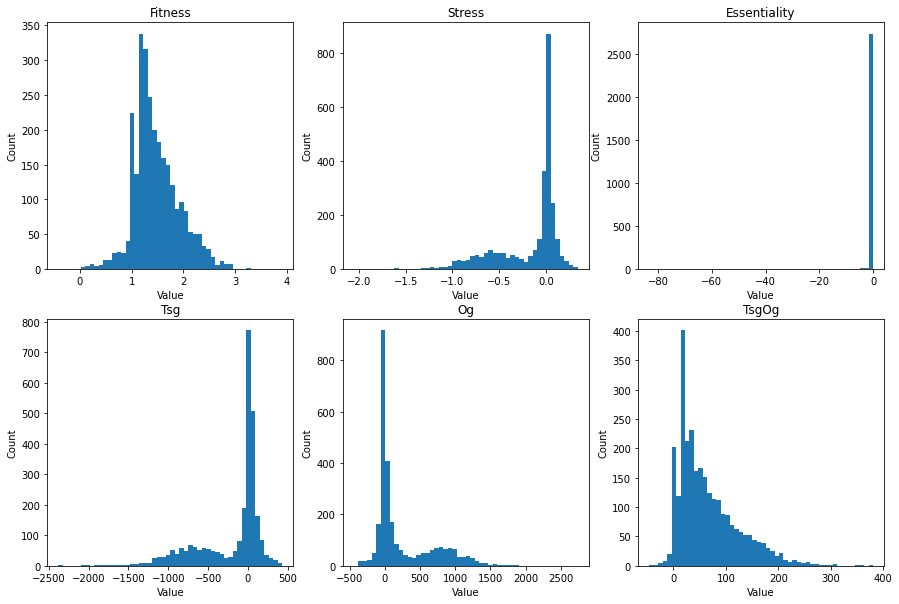

In [89]:
bin_count = 50 if use_sample else 20

# create 6 subplots 2*3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# plot the data
for x in range(2):
    for y in range(3):
        axes[x, y].set_xlabel('Value')
        axes[x, y].set_ylabel('Count')
        axes[x, y].set_title(columns[x*3+y])    
        axes[x, y].hist(data[columns[x*3+y]], bins=bin_count)

In [86]:
data.loc["1bea3a72-3b73-4072-a6bb-96a90119d3ac"]

Fitness           1.8109
Stress            0.1963
Tsg            -253.3605
Og              314.8246
Essentiality      0.0000
TsgOg            61.4641
Name: 1bea3a72-3b73-4072-a6bb-96a90119d3ac, dtype: float64

In [90]:
data[data["Fitness"] < 0]

,Fitness,Stress,Tsg,Og,Essentiality,TsgOg
Id,,,,,,
518d6c1b-8234-40be-9560-6d383d5866fa,-0.4180,-1.2123,-1470.9900,1450.4195,0.0,-20.5705
5650dc4e-8bce-4716-9199-cd5750d7a888,-0.2538,-0.7945,-998.4161,952.4844,0.0,-45.9317


In [91]:
data["Essentiality"].min()
# data where essentiality is min
data[data["Essentiality"] == data["Essentiality"].min()]

,Fitness,Stress,Tsg,Og,Essentiality,TsgOg
Id,,,,,,
5ab6a1d3-76f8-45d4-a430-d9831daa9ec4,0.5233,-0.0011,-42.9634,78.6691,-83.2671,35.7057


Text(0.5, 0, '$\\Delta(F)$')

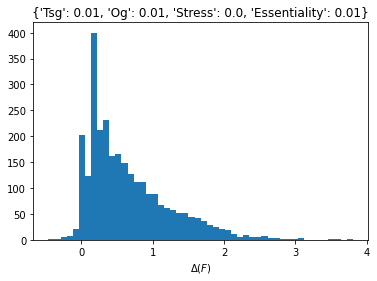

In [77]:
params =  {"Tsg": 0.01, "Og": 0.01, "Stress": 0.01, "Essentiality": 0.01 }
myfun = lambda x : (params[x] * data[x]).to_numpy()
mySum = sum(map(myfun, params.keys()))
plt.title(f"{params}")
plt.hist(mySum, bins=bin_count);
plt.xlabel('$\Delta(F)$')

In [70]:
ser = pd.Series(mySum)
ser[ser < -1]

1666   -1.418005
2767   -1.253817
dtype: float64

Text(0, 0.5, 'Og')

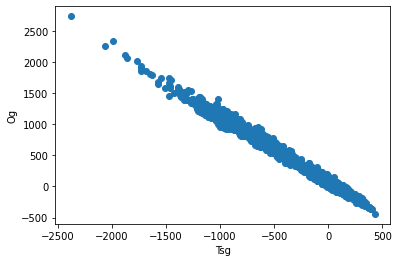

In [71]:
plt.scatter(data["Tsg"], data["Og"]);
plt.xlabel("Tsg")
plt.ylabel("Og")

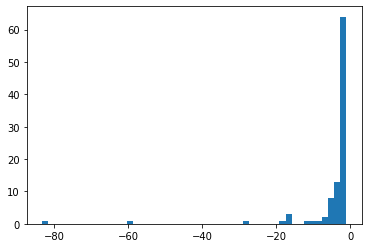

In [92]:
plt.hist(data["Essentiality"][data["Essentiality"] < -1], bins=bin_count);

In [94]:
data["Essentiality"][data["Essentiality"] < -1].count()

97

(array([ 93., 245., 804., 383., 147.,  60.,  46.,  24.,  16.,   8.]),
 array([-0.0982 , -0.05447, -0.01074,  0.03299,  0.07672,  0.12045,
         0.16418,  0.20791,  0.25164,  0.29537,  0.3391 ]),
 <BarContainer object of 10 artists>)

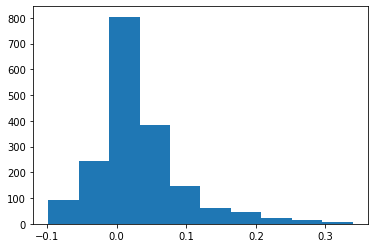

In [74]:
plt.hist(data["Stress"][data["Stress"] > -0.1])

In [9]:
data["Stress"][data["Stress"] >= 0].min()

0.0

In [10]:
data["Stress"][data["Stress"] == 0]

Id
0-0       0.0
3583-1    0.0
7237-1    0.0
7735-1    0.0
Name: Stress, dtype: float64

In [ ]:
data["Essentiality"][data["Essentiality"] < -300]

Id
931b24da-5d6d-4c2d-8de9-ef32d6eb8565   -332.6031
Name: Essentiality, dtype: float64